## 데이터 불러오기

In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = housing.data
y = housing.target

In [ ]:
X.shape
y.shape

(20640,)

## 데이터 확인

In [ ]:
import pandas as pd

print("feature names: ",housing.feature_names )

print("\n\n")

print("Data type of X:", type(X))
print("Shape of X:", X.shape)
print("Data type of y:", type(y))
print("Shape of y:", y.shape)

print("\n\n")

print("Number of missing values in X:\n", pd.DataFrame(X, columns=housing.feature_names).isnull().sum())
print("Number of missing values in y:", pd.Series(y).isnull().sum())

feature names:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']



Data type of X: <class 'numpy.ndarray'>
Shape of X: (20640, 8)
Data type of y: <class 'numpy.ndarray'>
Shape of y: (20640,)



Number of missing values in X:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Number of missing values in y: 0


In [ ]:
from torch.utils.data import DataLoader, TensorDataset,random_split

# 데이터를 Tesnor로 변환
X_tensor = torch.tensor(X).float()
y_tensor = torch.tensor(y).float()

## 데이터 스케일링

In [ ]:
def min_max_scaling(tensor):
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)
    return (tensor - min_val) / (max_val - min_val)

def z_score_normalization(tensor):
    mean = torch.mean(tensor)
    std = torch.std(tensor)
    return (tensor - mean) / std

In [ ]:
X_tensor = min_max_scaling(X_tensor)
y_tensor = y_tensor.unsqueeze(1)

## 이상치 제거

In [ ]:
print(X_tensor.size())
print(y_tensor.size())

torch.Size([20640, 8])
torch.Size([20640, 1])


In [ ]:
def remove_outliers(x, y, threshold=2):
    # Z-score 계산
    mean = torch.mean(x, dim=0)
    std = torch.std(x, dim=0)
    z_scores = (x - mean) / std

    # 각 행에서 Z-score의 절대값이 threshold보다 큰 값이 있는지 확인
    abs_z_scores = torch.abs(z_scores)
    mask = abs_z_scores < threshold
    valid_rows = torch.all(mask, dim=1)

    # 이상치가 아닌 행만 필터링
    return x[valid_rows], y[valid_rows]

# 함수 사용
X_tensor, y_tensor = remove_outliers(X_tensor, y_tensor)


In [ ]:
print(X_tensor.size())
print(y_tensor.size())

torch.Size([18220, 8])
torch.Size([18220, 1])


## 데이터로더 생성

In [ ]:
dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Torch를 사용해서 구현

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.init as init

## 모델 구현

In [ ]:
import torch.nn as nn
import torch.nn.init as init

class MLP_Regressoion(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP_Regressoion, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim[0])
        self.bn1 = nn.BatchNorm1d(hidden_dim[0])
        self.fc2 = nn.Linear(hidden_dim[0], hidden_dim[1])
        self.bn2 = nn.BatchNorm1d(hidden_dim[1])
        self.fc3 = nn.Linear(hidden_dim[1], hidden_dim[2])
        self.bn3 = nn.BatchNorm1d(hidden_dim[2])
        self.fc4 = nn.Linear(hidden_dim[2], hidden_dim[3])
        self.bn4 = nn.BatchNorm1d(hidden_dim[3])
        self.fc5 = nn.Linear(hidden_dim[3], hidden_dim[4])
        self.bn5 = nn.BatchNorm1d(hidden_dim[4])
        self.fc6 = nn.Linear(hidden_dim[4], hidden_dim[5])
        self.bn6 = nn.BatchNorm1d(hidden_dim[5])
        self.fc7 = nn.Linear(hidden_dim[5], output_dim)

        # 모든 모듈을 순회하며 초기화
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.kaiming_normal_(m.weight, nonlinearity='relu')
                init.zeros_(m.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = torch.relu(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = torch.relu(x)

        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)

        x = self.fc7(x)
        return x

input_dim = 8
hidden_dim = [64, 64, 32, 16, 8, 4]
output_dim = 1
model = MLP_Regressoion(input_dim, hidden_dim, output_dim)


## loss and optimizer

In [ ]:
criterion = nn.MSELoss()  # 평균 제곱 오차 손실 (회귀 문제에 적합)
optimizer = optim.SGD(model.parameters(), lr=0.0001)  # 확률적 경사하강법

In [ ]:
# Early Stopping 변수들
patience = 30  # 개선되지 않는 에폭 허용 횟수
best_loss = float('inf')
counter = 0

for epoch in range(1000):
    # Training loop
    model.train()
    train_losses = []  # 학습 손실들을 저장할 리스트
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        train_losses.append(loss.item())  # 학습 손실값 추가
        loss.backward()
        optimizer.step()

    avg_train_loss = sum(train_losses) / len(train_losses)  # 평균 학습 손실 계산

    # Validation loop
    model.eval()
    val_losses = []  # 검증 손실들을 저장할 리스트
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_losses.append(loss.item())

    # 평균 검증 손실 계산
    avg_val_loss = sum(val_losses) / len(val_losses)

    # patience의 배수의 에폭마다 손실값 출력
    if (epoch + 1) % patience == 0:
        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}")

    # Early Stopping
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping!")
            break


Epoch 30, Train Loss: 1.232100905776024, Validation Loss: 1.2449648705395786
Epoch 60, Train Loss: 1.0409904766082763, Validation Loss: 1.1832778182896702
Epoch 90, Train Loss: 0.9047035038471222, Validation Loss: 0.8804166533730247
Epoch 120, Train Loss: 0.8529449617862701, Validation Loss: 0.9960481090979143
Epoch 150, Train Loss: 0.8055726516246796, Validation Loss: 0.9179149568080902
Epoch 180, Train Loss: 0.7412462157011032, Validation Loss: 0.8242959515614943
Epoch 210, Train Loss: 0.6975700044631958, Validation Loss: 0.733353937214071
Epoch 240, Train Loss: 0.6723087292909622, Validation Loss: 0.7377356074073098
Epoch 270, Train Loss: 0.6389997947216034, Validation Loss: 0.7377117763866078
Epoch 300, Train Loss: 0.6234971475601196, Validation Loss: 0.6219391578977759
Epoch 330, Train Loss: 0.5957802593708038, Validation Loss: 0.6271520582112399
Epoch 360, Train Loss: 0.5746744215488434, Validation Loss: 0.5676631331443787
Early Stopping!


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 모델 평가 모드로 설정
model.eval()

# 예측 및 실제 값을 저장할 리스트
predictions = []
true_values = []
test_losses = []  # 테스트 손실을 저장할 리스트 추가

# 그라디언트 계산 비활성화
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)

        # 각 배치의 손실 계산 및 저장
        loss = criterion(outputs, batch_y)
        test_losses.append(loss.item())

        predictions.extend(outputs.numpy().flatten())
        true_values.extend(batch_y.numpy().flatten())

# 테스트 손실의 평균 계산
avg_test_loss = sum(test_losses) / len(test_losses)
print(f"Average Test Loss: {avg_test_loss:.4f}")

# RMSE 계산
rmse = np.sqrt(mean_squared_error(true_values, predictions))
print(f"RMSE: {rmse:.4f}")

# R^2 계산
r2 = r2_score(true_values, predictions)
print(f"R^2: {r2:.4f}")

Average Test Loss: 0.6608
RMSE: 0.8107
R^2: 0.4071


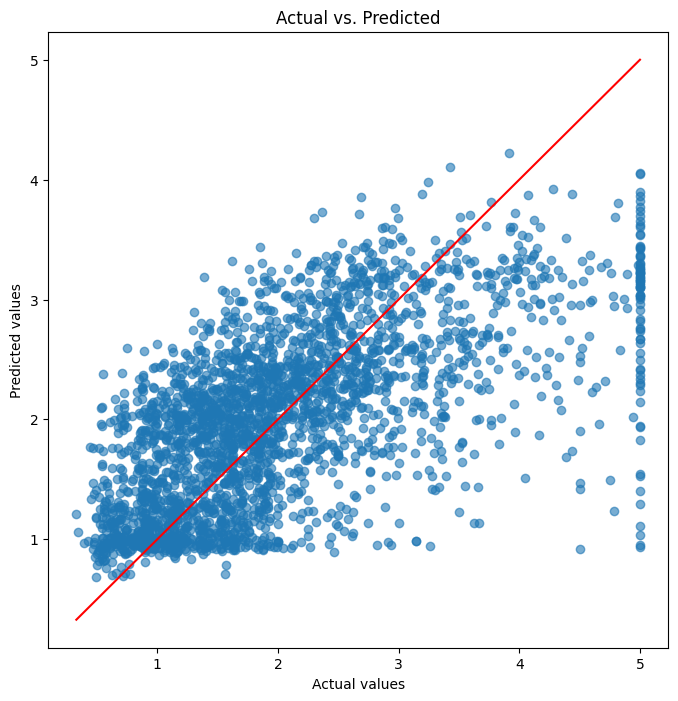

In [ ]:
import matplotlib.pyplot as plt

# 실제값과 예측값의 scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(true_values, predictions, alpha=0.6)
plt.plot([min(true_values), max(true_values)], [min(true_values), max(true_values)], 'r')  # y=x 라인
plt.title("Actual vs. Predicted")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()


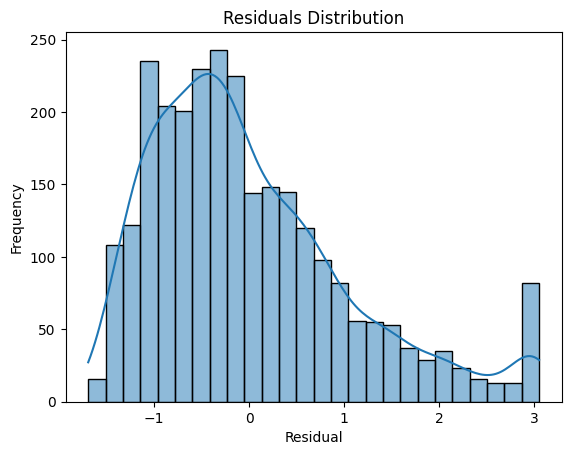

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 예측된 값들로부터 실제 값들을 빼서 잔차를 계산합니다.
residuals = np.array(true_values) - np.array(predictions)

# 잔차 분포 플롯
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()